In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime
# from scipy.ndimage import gaussian_filter

In [2]:
def F_to_C(temp_array,reverse=False):
    if reverse: # C to F
        c_array = np.array(temp_array)  # make sure it's a numpy array
        converted_array = c_array*9/5 + 32 
    else: # F to C
        f_array = np.array(temp_array) 
        converted_array = (f_array - 32)*5/9
    return converted_array

In [12]:
!conda install openpyxl

Retrieving notices: ...working... done
Solving environment: \ 
The environment is inconsistent, please check the package plan carefully
The following packages are causing the inconsistency:

  - conda-forge/osx-64::postgresql==13.5=he8fe76e_1
  - conda-forge/osx-64::poppler==21.03.0=h640f9a4_0
  - conda-forge/osx-64::libopencv==4.5.0=py38_6
  - conda-forge/osx-64::gdal==3.1.4=py38h793d2a3_18
  - conda-forge/osx-64::cairo==1.16.0=he43a7df_1008
  - conda-forge/osx-64::libdap4==3.20.6=h3e144a0_2
  - conda-forge/osx-64::boost-cpp==1.77.0=hff03dee_0
  - conda-forge/osx-64::libspatialite==5.0.1=h035f608_6
  - conda-forge/osx-64::fontconfig==2.13.94=h10f422b_0
  - conda-forge/osx-64::py-opencv==4.5.0=py38h9bb44b7_6
  - conda-forge/osx-64::harfbuzz==2.9.1=h159f659_1
  - conda-forge/osx-64::libxml2==2.9.12=h93ec3fd_0
  - conda-forge/osx-64::libgdal==3.1.4=h85d2021_18
  - conda-forge/osx-64::opencv==4.5.0=py38_6
  - conda-forge/osx-64::rasterio==1.2.0=py38h7c93fde_0
  - conda-forge/osx-64::autor

# Haenke Island weather data

In [8]:
# find files
basepath = '/Users/jukesliu/Documents/TURNER/DATA/WEATHER/wx_from_crrel_202209/'
os.listdir(basepath)

['2019Jan_2019Jun_HUBWeather.xlsx',
 '2018Jul_2018Dec_HUBWeather.xlsx',
 '2017Jul_2017Dec_HUBWeather.xlsx',
 'wx_Haenke_2014_2022_weekly_elevcorrected18km.csv',
 '2015Jul_2015Dec_HUBWeather.xlsx',
 '2021Nov_2022Sept22_HUBWeather.xlsx',
 '~$2020Jul_2021Jan_HUBWeather.xlsx',
 'wx_Haenke_2014_2022_nogap.csv',
 '2016Jan_2016Jun_HUBWeather.xlsx',
 '2014Jan_2014Jun_HUBWeather.xlsx',
 '2013Jul_2013Dec_HUBWeather.xlsx',
 'wx-2020-oct-20-to-2021-sep-28.csv',
 '2018Jan_2018Jun_HUBWeather.xlsx',
 '2020Jul_2021Jan_HUBWeather.xlsx',
 '2019Jul_2029Dec_HUBWeather.xlsx',
 '2020Jan_2020Jun_HUBWeather.xlsx',
 'wx_Haenke_2013_2022_dailyavg.csv',
 'wx_Haenke_2014_2022_daily_elevcorrected18km.csv',
 '2021Jan_2021Oct_HUBWeather.xlsx',
 'wx_Haenke_2013_2022.csv',
 'wx_Haenke_2014_2022_weekly_elevcorrected.csv',
 '2016Jul_2016Dec_HUBWeather.xlsx',
 '2013Jan_2013Jun_HUBWeather.xlsx',
 '2014Jul_2014Dec_HUBWeather.xlsx',
 '2017Jan_2017Jun_HUBWeather.xlsx',
 'wx_Haenke_2014_2022_elevcorrected.csv',
 '2015Jan_2015

In [9]:
# # explore one
# file = '2019Jan_2019Jun_HUBWeather.xlsx'
# df = pd.read_excel(basepath+file, skiprows=[0,1,3,4,5,6])
# df.head()

In [32]:
# grab all 6 month files
dfs = []
for file in os.listdir(basepath):
    if file.startswith('2'):
        df = pd.read_excel(basepath+file, skiprows=[0,1,3,4,5,6]) # read in as a dataframe
        dfs.append(df)

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [6]:
# concatenate all files together
all_df = pd.concat(dfs)
all_df = all_df.sort_values(by='GMT')
all_df = all_df.reset_index()

# drop all unused columns
all_df = all_df.drop(columns=['index', 'C', '%-RELHUM', 'Dir-WIND1', 'Dir-WIND2', 'Pres',
       'Rad-SOLARDN', 'Rad-SOLARUP', 'Speed-WIND1', 'Speed-WIND2'])
all_df.head()

NameError: name 'dfs' is not defined

In [48]:
wxpath = '/Users/jukesliu/Documents/TURNER/DATA/WEATHER/wx_from_crrel_202209/'
w1_df = pd.read_csv(wxpath+'wx-2020-oct-20-to-2021-sep-28.csv')
w1_df.head()

# w1_df['GMT'] pd.to_datetime(w1_df.Date)

# convert date and time column to datetime (GMT)
# w1_df['GMT'] = pd.to_datetime(w1_df.Date) + (pd.to_datetime(w1_df.Time) - datetime.datetime(2022,11,1))
w1_df['GMT'] = pd.to_datetime(w1_df.Date) + (pd.to_timedelta(w1_df.Time))

# convert temperatures from Celsuis to F to match the other data 
w1_df['Temp-AIR1'] = F_to_C(w1_df.Air_Temp1, reverse=True)
w1_df['Temp-AIR2'] = F_to_C(w1_df.Air_Temp2, reverse=True)
w1_df['Temp-AVG'] = (np.array(w1_df['Temp-AIR1'])+np.array(w1_df['Temp-AIR2']))/2
# drop unused columns
w1_df = w1_df.drop(columns=['Date','Time','Rel_Hum','Wind_Spd1','Wind_Dir1','Wind_Spd2','Wind_Dir2','Bar_Pres','Solar_Up',
           'Solar_Down','Volts','Air_Temp1','Air_Temp2'])
w1_df

/var/folders/mr/7f69f7y50zj85n420pyvh8cr0000gq/T/ipykernel_38231/312513911.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  w1_df['GMT'] = pd.to_datetime(w1_df.Date) + (pd.to_timedelta(w1_df.Time))


,GMT,Temp-AIR1,Temp-AIR2,Temp-AVG
0,2020-10-20 04:00:00,38.12,37.58,37.85
1,2020-10-20 04:15:00,38.48,37.76,38.12
2,2020-10-20 04:30:00,39.38,38.48,38.93
3,2020-10-20 04:45:00,39.56,38.66,39.11
4,2020-10-20 05:00:00,39.38,38.66,39.02
...,...,...,...,...
29719,2021-09-28 02:45:00,46.04,45.14,45.59
29720,2021-09-28 03:00:00,44.78,44.42,44.60
29721,2021-09-28 03:15:00,44.24,43.70,43.97
29722,2021-09-28 03:30:00,41.36,40.82,41.09


In [ ]:
# add the new data into all_df
all_df = pd.concat([all_df, w1_df])

In [ ]:
# calculate average temperatures
temp1 = np.array(all_df['Temp-AIR1'])
temp2 = np.array(all_df['Temp-AIR2'])
all_df['Temp-AVG'] = (temp1+temp2)/2 # average the two temperatures

# convert GMT times to local AK times!!
datetimes = pd.to_datetime(all_df['GMT'])
AKDT = datetimes - datetime.timedelta(hours=8) 
all_df['AKDT'] = AKDT # add back to dataframe
all_df.head()

In [ ]:
plt.plot(all_df.AKDT, all_df['Temp-AVG'], '-')
plt.show()

In [ ]:
# write to csv
all_df.to_csv(basepath+'wx_Haenke_2014_2023_nogap.csv', index=False)

In [42]:
w2_df = pd.read_csv(basepath+'2021Nov_2022Sept22_HUBWeather.csv',skiprows=[0,1,3,4,5,6])
w2_df = w2_df.dropna()
w2_df.GMT = pd.to_datetime(w2_df.GMT)
w2_df['Temp-AVG'] = (np.array(w2_df['Temp-AIR1'])+np.array(w2_df['Temp-AIR2']))/2
w2_df

,C,GMT,%-RELHUM,Dir-WIND1,Dir-WIND2,Pres,Rad-SOLARDN,Rad-SOLARUP,Speed-WIND1,Speed-WIND2,Temp-AIR1,Temp-AIR2,Temp-AVG
0,1,2021-11-01 00:00:00,100.0,348.0,359.0,29.861,0.031327,0.001082,3.579,2.908,44.06,43.34,43.70
1,2,2021-11-01 00:15:00,100.0,346.0,2.0,29.858,0.031327,0.000701,4.250,3.132,43.88,42.98,43.43
2,3,2021-11-01 00:30:00,100.0,333.0,338.0,29.855,0.031327,0.000470,10.290,6.935,44.06,43.16,43.61
3,4,2021-11-01 00:45:00,100.0,323.0,307.0,29.855,0.031327,0.000293,10.290,8.053,43.70,42.80,43.25
4,5,2021-11-01 01:00:00,100.0,330.0,329.0,29.852,0.031327,0.000113,11.185,7.158,43.70,42.98,43.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31267,31268,2022-09-22 16:45:00,100.0,10.0,11.0,29.613,0.031327,0.007412,6.711,5.592,40.82,39.92,40.37
31268,31269,2022-09-22 17:00:00,100.0,4.0,8.0,29.616,0.031327,0.000961,4.698,3.355,40.10,39.02,39.56
31269,31270,2022-09-22 17:15:00,100.0,38.0,8.0,29.619,0.031327,0.000868,3.355,1.566,39.92,39.02,39.47
31270,31271,2022-09-22 17:30:00,100.0,336.0,335.0,29.622,0.031327,0.000684,3.132,2.908,40.46,39.38,39.92


### Calculate daily average temperature

In [75]:
all_df = pd.read_csv(basepath+'wx_Haenke_2013_2022.csv')
all_df = all_df.dropna()
all_df = pd.concat([all_df,w1_df,w2_df],join='outer') # concatenate

datetimes = pd.to_datetime(all_df['GMT'])
AKDT = datetimes - datetime.timedelta(hours=8) 
all_df['AKDT'] = AKDT # add back to dataframe
all_df.AKDT = pd.to_datetime(all_df.AKDT)
all_df['Tavg_C'] = F_to_C(all_df['Temp-AVG'])
all_df.to_csv(basepath+'wx_Haenke_2017_2023_continuous.csv')
all_df = all_df.drop(['GMT'], axis=1)

# calculate daily mean
all_df = all_df.set_index('AKDT')
daily_df = all_df.groupby(pd.Grouper(freq='D')).mean()

AttributeError: 'DataFrameGroupBy' object has no attribute 'nanmean'

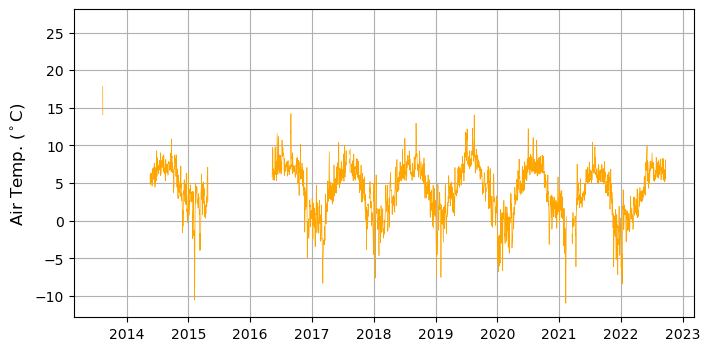

In [72]:
# plot
fig, ax = plt.subplots(1, figsize=(8,4))
fs = 12

# plot temperature over time
# ax.plot(all_df['AKDT'], F_to_C(all_df['Temp-AVG'
#                                ]),linewidth=0.2,color='orange', alpha=0.3) # full resolution
ax.plot(daily_df.index, F_to_C(daily_df['Temp-AVG']), linewidth=0.5,color='orange') # daily resolution
ax.grid()
ax.set_ylabel('Air Temp. ($^\circ$C)',fontsize=fs)
plt.show()

In [74]:
daily_df.to_csv(basepath+'wx_Haenke_2017_2023_continuous_dailyavg.csv')

In [51]:
# create an array of datetimes
d0 = all_df.loc[0,'AKDT'] # first date
d1 = all_df.loc[len(all_df)-1,'AKDT'] # last date
dates = np.arange(datetime.datetime(d0.year,d0.month,d0.day), datetime.datetime(d1.year,d1.month,d1.day), 
          datetime.timedelta(days=1)).astype(datetime.datetime)

day = []; daily_temp = []
for a in range(0, len(dates)):
    if a == len(dates)-1:
        day_df = all_df[(all_df.AKDT >= dates[a])]
    else:
        day_df = all_df[(all_df.AKDT >= dates[a]) & (all_df.AKDT < dates[a+1])]
    dayT = np.nanmean(day_df['Temp-AVG'])
    daily_temp.append(dayT)
    day.append(dates[a])
    
daily_df = pd.DataFrame(list(zip(day, daily_temp)), columns=['date','Temp-AVG'])
daily_df

AttributeError: 'Series' object has no attribute 'year'

In [11]:
daily_df.to_csv(basepath+'wx_Haenke_2013_2022_dailyavg.csv', index=False)

### Plot:

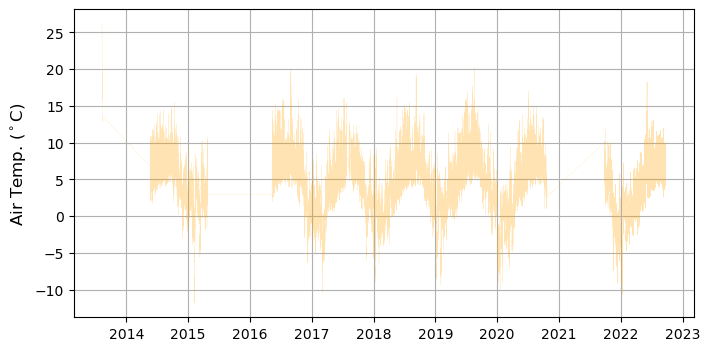

In [45]:
# plot
fig, ax = plt.subplots(1, figsize=(8,4))
fs = 12

# plot temperature over time
ax.plot(all_df['AKDT'], F_to_C(all_df['Temp-AVG']),linewidth=0.2,color='orange', alpha=0.3) # full resolution
# ax.plot(daily_df['date'], F_to_C(daily_df['Temp-AVG']), linewidth=0.5,color='orange') # daily resolution
ax.grid()
ax.set_ylabel('Air Temp. ($^\circ$C)',fontsize=fs)
plt.show()

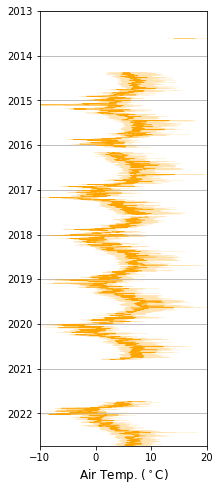

In [13]:
# plot
fig, ax = plt.subplots(1, figsize=(3,8))
fs = 12

# plot temperature over time
ax.plot(F_to_C(all_df['Temp-AVG']),all_df['AKDT'], linewidth=0.2,color='orange', alpha=0.3) # full resolution
ax.plot(F_to_C(daily_df['Temp-AVG']), daily_df['date'], linewidth=0.5,color='orange') # daily resolution
ax.grid(axis='y')
ax.set_xlabel('Air Temp. ($^\circ$C)',fontsize=fs)
ax.set_ylim(d1,d0); ax.set_xlim(-10,20)
plt.show()